# Tech stocks vs S&P 500

Daily and cumulative returns for AAPL, MSFT, NVDA, META against the S&P 500 (`^GSPC`).

In [15]:
import datetime

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [16]:
stocks = ["AAPL", "MSFT", "NVDA", "META"]
benchmark = "^GSPC"  # S&P 500 index
tickers = stocks + [benchmark]

start_date = datetime.date(2020, 1, 1)
end_date = datetime.date.today()

## Download prices

In [17]:
df = yf.download(tickers, start_date, end_date, auto_adjust=True)
prices = df["Close"].rename(columns={benchmark: "SP500"})
prices.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,META,MSFT,NVDA,SP500
Date,,,,,
2020-01-02,72.271538,207.953842,151.544281,5.957138,3257.850098
2020-01-03,71.568886,206.853500,149.657288,5.861788,3234.850098
2020-01-06,72.139206,210.749313,150.044098,5.886370,3246.280029
2020-01-07,71.799927,211.205276,148.676041,5.957635,3237.179932
2020-01-08,72.954918,213.346481,151.044235,5.968807,3253.050049


In [18]:
# clean it
prices = prices.dropna()
prices.shape

(1683, 5)

## Daily returns

In [19]:
returns = prices.pct_change().dropna()
returns.head()

Ticker,AAPL,META,MSFT,NVDA,SP500
Date,,,,,
2020-01-03,-0.009722,-0.005291,-0.012452,-0.016006,-0.007060
2020-01-06,0.007969,0.018834,0.002585,0.004194,0.003533
2020-01-07,-0.004703,0.002164,-0.009118,0.012107,-0.002803
2020-01-08,0.016086,0.010138,0.015929,0.001875,0.004902
2020-01-09,0.021241,0.014311,0.012493,0.010983,0.006655


In [20]:
returns.describe()

Ticker,AAPL,META,MSFT,NVDA,SP500
count,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000
mean,0.001103,0.001074,0.000899,0.002653,0.000587
std,0.019754,0.027524,0.019152,0.032692,0.012766
min,-0.128647,-0.263901,-0.147390,-0.184521,-0.119841
25%,-0.008195,-0.011870,-0.008465,-0.015468,-0.004781
50%,0.001148,0.001029,0.000933,0.002826,0.000895
75%,0.011227,0.014000,0.010519,0.021271,0.006740
max,0.153289,0.232824,0.155067,0.243696,0.095154


## Cumulative returns

In [21]:
# growth of $1 invested at the start
cum_returns = (1 + returns).cumprod()
cum_returns.tail()

Ticker,AAPL,META,MSFT,NVDA,SP500
Date,,,,,
2026-09-08,4.375443,2.950078,3.259443,37.850006,2.355394
2026-09-09,4.363267,3.143438,3.244266,37.504589,2.343987
2026-09-10,4.518653,3.098668,3.249479,36.655188,2.330279
2026-09-11,4.597522,3.116221,3.270529,36.643437,2.350317
2026-09-14,4.608730,3.200710,3.335065,35.412982,2.338960


In [22]:
# total return over the period, best to worst
(cum_returns.iloc[-1] - 1).sort_values(ascending=False).map("{:+.1%}".format)

Ticker
NVDA     +3441.3%
AAPL      +360.9%
MSFT      +233.5%
META      +220.1%
SP500     +133.9%
Name: 2026-09-14 00:00:00, dtype: str

## Plot

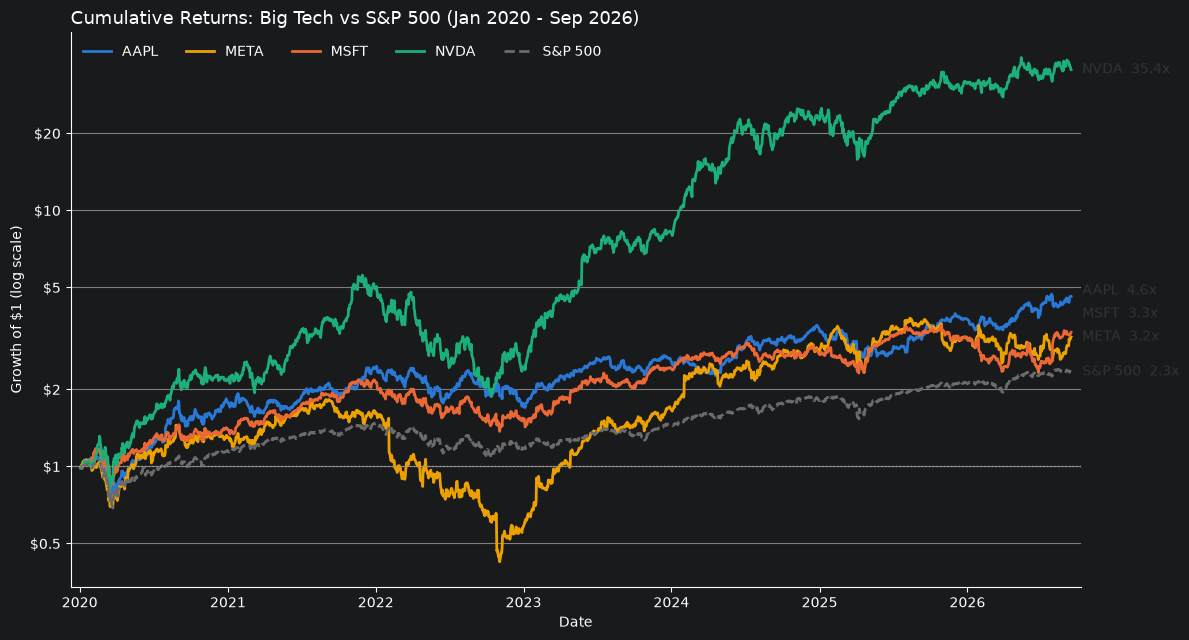

In [23]:
colors = {
    "AAPL": "#2a78d6",   # blue
    "MSFT": "#eb6834",   # orange
    "NVDA": "#1baf7a",   # aqua
    "META": "#eda100",   # yellow
    "SP500": "#6b6b6b",  # benchmark in neutral gray
}

fig, ax = plt.subplots(figsize=(12, 6.5))

for col in cum_returns.columns:
    ax.plot(cum_returns.index, cum_returns[col], color=colors[col], linewidth=2,
            linestyle="--" if col == "SP500" else "-", label="S&P 500" if col == "SP500" else col)

# direct labels at the right edge, nudged apart so they don't overlap (log space)
last = cum_returns.iloc[-1].sort_values()
min_gap = 0.09  # in log10 units
ypos = np.log10(last.values)
for i in range(1, len(ypos)):
    ypos[i] = max(ypos[i], ypos[i - 1] + min_gap)
for (col, val), y in zip(last.items(), 10 ** ypos):
    name = "S&P 500" if col == "SP500" else col
    ax.annotate(f"{name}  {val:.1f}x", xy=(cum_returns.index[-1], y), xytext=(8, 0),
                textcoords="offset points", va="center", fontsize=10, color="#333333")

ax.axhline(1, color="#999999", linewidth=1, linestyle=":")  # break-even
ax.set_yscale("log")
ax.yaxis.set_major_locator(mtick.LogLocator(base=10, subs=(1, 2, 5)))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v:g}"))
ax.yaxis.set_minor_locator(mtick.NullLocator())
ax.set_title(f"Cumulative Returns: Big Tech vs S&P 500 "
             f"({cum_returns.index[0]:%b %Y} - {cum_returns.index[-1]:%b %Y})",
             fontsize=13, loc="left")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1 (log scale)")
ax.grid(axis="y", which="major", color="#e5e5e5", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", frameon=False, ncol=5)
ax.margins(x=0.01)
fig.tight_layout()
plt.show()


In [24]:
returns.corr()

Ticker,AAPL,META,MSFT,NVDA,SP500
Ticker,,,,,
AAPL,1.000000,0.514667,0.638869,0.542802,0.753997
META,0.514667,1.000000,0.559858,0.516491,0.615852
MSFT,0.638869,0.559858,1.000000,0.623754,0.756339
NVDA,0.542802,0.516491,0.623754,1.000000,0.699484
SP500,0.753997,0.615852,0.756339,0.699484,1.000000


## Beta vs S&P 500

$eta_i = \dfrac{\mathrm{Cov}(r_i, r_m)}{\mathrm{Var}(r_m)}$ — computed from daily returns over the full period.

In [25]:
market = returns["SP500"]
cov = returns[stocks].apply(lambda r: r.cov(market))
betas = (cov / market.var()).rename("beta")

# alpha is the intercept of the OLS line r_i = alpha + beta * r_m (annualised, 252 trading days)
alphas = (returns[stocks].mean() - betas * market.mean()) * 252
corr = returns[stocks].corrwith(market)

beta_table = pd.DataFrame({"beta": betas, "alpha_annual": alphas, "corr_with_SP500": corr})
beta_table.sort_values("beta", ascending=False).round(3)

,beta,alpha_annual,corr_with_SP500
Ticker,,,
NVDA,1.791,0.404,0.699
META,1.328,0.074,0.616
AAPL,1.167,0.105,0.754
MSFT,1.135,0.059,0.756


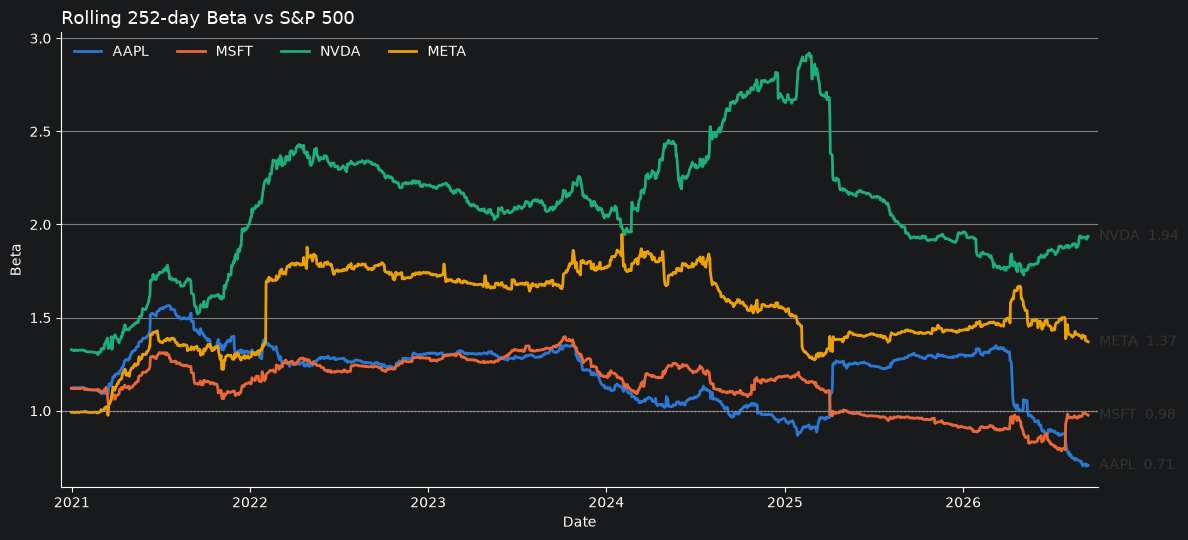

In [26]:
# rolling 1-year beta to see how it changes over time
window = 252
rolling_beta = returns[stocks].rolling(window).cov(market).div(market.rolling(window).var(), axis=0).dropna()

fig, ax = plt.subplots(figsize=(12, 5.5))
for col in stocks:
    ax.plot(rolling_beta.index, rolling_beta[col], color=colors[col], linewidth=2, label=col)
    ax.annotate(f"{col}  {rolling_beta[col].iloc[-1]:.2f}",
                xy=(rolling_beta.index[-1], rolling_beta[col].iloc[-1]), xytext=(8, 0),
                textcoords="offset points", va="center", fontsize=10, color="#333333")

ax.axhline(1, color="#999999", linewidth=1, linestyle=":")  # market beta
ax.set_title(f"Rolling {window}-day Beta vs S&P 500", fontsize=13, loc="left")
ax.set_xlabel("Date")
ax.set_ylabel("Beta")
ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", frameon=False, ncol=4)
ax.margins(x=0.01)
fig.tight_layout()
plt.show()